In [92]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

from functools import partial
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tqdm
import torch
from torch import nn, tensor, Tensor
from typing import Any, Literal, Iterable

import block_formats.analysis as A
import block_formats.experiments as E
import block_formats.fit as F
import block_formats.quantisation as Q
import block_formats.sensitivity as S

matplotlib.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False})
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:
model = E.RequantisableModel.load("meta-llama/Llama-3.2-1B", DEVICE, torch.bfloat16)
params = {k: v.detach() for k, v in model.model.named_parameters() if v.ndim == 2}
data = E.Dataset.load_wikitext2(model.model, sequence_length=256, batch_size=16, kl_topk=128, sequence_limit=128)
data_train = E.Dataset.load_wikitext2(model.model, sequence_length=256, batch_size=16, kl_topk=128, sequence_limit=128, split="train")

def evaluate_model() -> dict[str, float]:
    """Evaluate the current model and return (cross_entropy, cross_entropy_stderr, kl_div, kl_div_stderr) in a dict."""
    results = data.evaluate(model.model)
    return {k: v
            for metric, samples in results.items()
            for k, v in {
                metric: samples.mean().item(), f"{metric}_stderr": samples.std().item() / len(samples)**.5
            }.items()}

In [124]:
def absolute_sensitivity(model: nn.Module, loss: str, progress: bool = False) -> dict[str, Tensor]:
    S.LinearGradSqWrapper.wrap(model)
    try:
        model.zero_grad()
        for index in tqdm.tqdm(list(range(data_train.n_batch)), disable=not progress):
            losses = data_train.batch_losses(model, index)
            # Compute as a sum - scaling by sequence_length to cancel the mean-over-sequence
            losses[loss].backward(torch.full_like(losses[loss], data_train.sequence_length))
        name_to_sensitivity = {}
        for name, m in model.named_modules():
            if isinstance(m, S.LinearGradSqWrapper):
                # Convert to a mean over batch and sequence
                name_to_sensitivity[f"{name}.weight"] \
                    = m.wrapped.weight.grad / (data_train.masks.sum() * data_train.sequence_length)
    finally:
        S.LinearGradSqWrapper.unwrap(model)
        model.zero_grad()
    return name_to_sensitivity

model.reset()
# sensitivity_kl = absolute_sensitivity(model.model, "kl_div", progress=True)
sensitivity_xent = absolute_sensitivity(model.model, "cross_entropy", progress=True)

100%|██████████| 8/8 [00:03<00:00,  2.05it/s]


### Using Fisher information to predict KL after additive Gaussian noise

In [125]:
def sweep() -> Iterable[dict[str, float]]:
    for scale in [1/64, 1/16, 1/4, 1]:
        for layer in [0, 4, 8, 12, 15]:  # subset for analysis & speed
            for name in [
                'self_attn.q_proj.weight',
                'self_attn.k_proj.weight',
                'self_attn.v_proj.weight',
                'self_attn.o_proj.weight',
                'mlp.gate_proj.weight',
                'mlp.up_proj.weight',
                'mlp.down_proj.weight',
            ]:
                parameter = f"model.layers.{layer}.{name}"
                model.reset()
                p = model.model.state_dict()[parameter]
                p[...] += torch.randn_like(p).mul_(scale * p.pow(2).mean().sqrt())
                yield dict(layer=layer, name=name, parameter=parameter, scale=scale, **evaluate_model())

df = pd.DataFrame.from_records(list(tqdm.tqdm(sweep())))

0it [00:00, ?it/s]

140it [02:16,  1.02it/s]


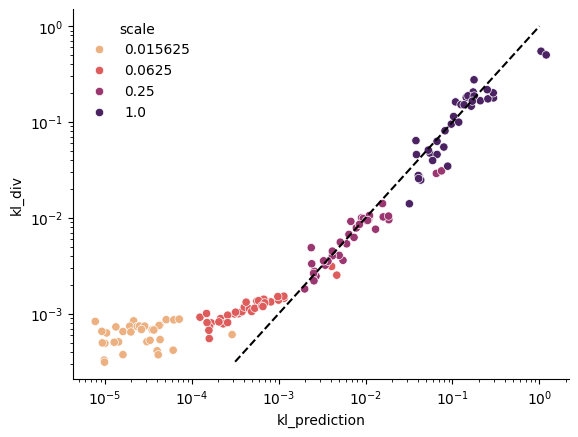

In [126]:
ax = sns.scatterplot(
    data=df.assign(kl_prediction=df.apply(
        # Using https://en.wikipedia.org/wiki/Fisher_information#Relation_to_relative_entropy
        lambda s: 0.5 * sensitivity_xent[s.parameter].sum().item() * params[s.parameter].pow(2).mean().item() * s.scale**2,
        axis=1)),
    y="kl_div", x="kl_prediction", hue="scale", palette="flare", hue_norm=matplotlib.colors.LogNorm())
ax.set_xscale("log")
ax.set_yscale("log")
xs = 10**torch.linspace(-3.5, 0, 101)
ax.plot(xs, xs, "k--")

---

# WIP

### Using Fisher information to predict KL from actual quantisation

### Does Fisher information identify the most sensitive elements?

For each parameter, perturb N weights according to
 - smallest/largest Fisher information
 - smallest/largest abs-value
 - random selection
 - smallest/largest RMS(activation) * abs(weight)

In [ ]:
# TODO

key = "model.layers.15.self_attn.k_proj.weight"

model.reset()
p = params[key]

n, s = 100, 1.0  # 0.00024283493985421956
n, s = 1000, 1.0  # 0.00036057416582480073 low: 0.00020181798026897013 high: 0.0023543681018054485 small: 0.0003783760475926101 large: 0.0005756129394285381

idx = torch.randperm(p.nelement())
idx = torch.argsort(sensitivity_xent[key].flatten()).flip(0)
idx = torch.argsort(p.abs().flatten()).flip(0)

p.flatten()[idx[:n]] += torch.randn(n, device=p.device, dtype=p.dtype) * s * p.pow(2).mean().sqrt()

data.evaluate(model.model)["kl_div"].mean().item()

0.0005756129394285381

### Try sensitivity as a weighting function for lloyd-max & for fitting quantiser hyperparameters.

In [ ]:
# TODO